# `pyblockencode` — block encoding periodic finite element operators

`pyblockencode` builds an LCU block encoding of a periodic finite element stiffness
matrix **without ever assembling the matrix**. You give it an operator and a size;
it returns a circuit and a report.

Six operators, all periodic:

| operator | $K$ | $L$ | $\alpha$ |
|---|---|---|---|
| `POISSON1D()` | $\mathrm{circ}(-1,2,-1)$ | 3 | 4 |
| `POISSON2D('fd')` | $K_1\otimes I + I\otimes K_1$ | 5 | 8 |
| `POISSON2D('fe')` | $K_1\otimes M_1 + M_1\otimes K_1$ | 9 | 16/3 |
| `ELASTICITY2D(nu)` | plane-stress Q4, 2 dof/node | 17 | $\frac{33+\nu}{6(1-\nu^2)}$ |
| `POISSON2D_2PHASE(vf, E1, E2)` | two-phase scalar cell | 25 | $\tfrac{16}{3}\max(E_1,E_2)$ |
| `ELASTICITY2D_2PHASE(nu, vf, E1, E2)` | two-phase plane-stress cell | 57 | $\dfrac{\tfrac12(E_1{+}E_2)(33{+}\nu)+|E_1{-}E_2|\left(18{+}2\nu{+}3|1{-}3\nu|\right)}{6(1-\nu^2)}$ |

with $K_1=\mathrm{circ}(-1,2,-1)$, $M_1=\tfrac16\mathrm{circ}(1,4,1)$,
$G_1=\tfrac12\mathrm{circ}(-1,0,1)$.

**$L$ and $\alpha$ do not depend on the problem size.** That is the whole point:
the decomposition is a property of the element, not of the mesh.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import qiskit 
from qiskit import QuantumCircuit
from pyblockencode import (blockencode, PeriodicBlockEncoding, increment_circuit,
                         POISSON1D, POISSON2D, ELASTICITY2D,
                         POISSON2D_2PHASE, ELASTICITY2D_2PHASE)

# categorical palette, fixed order, never cycled
SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300']
INK, MUTED, GRID = '#1a1a19', '#5c5c58', '#e4e4e0'
plt.rcParams.update({'figure.dpi': 120, 'font.size': 12,
                     'axes.edgecolor': MUTED, 'axes.labelcolor': INK,
                     'text.color': INK, 'xtick.color': MUTED,
                     'ytick.color': MUTED, 'grid.color': GRID,
                     'axes.spines.top': False, 'axes.spines.right': False})

FIG_DIR = 'figs'
LABEL_STAGES = True   # bracket each SELECT stage with a labelled barrier
FONT_SCALE   = 2.0    # multiplies Qiskit's default label sizes, 13 pt and 8 pt
FOLD         = -1     # gate columns per row; -1 draws the circuit in one row




print("Qiskit version:", qiskit.version.get_version_info())
def label_select_stages(qc, labels, tail=None, between=None, flag='s'):
    """Bracket each SELECT stage with barriers, labelling it.

    The pair of Toffolis that set and clear the select flag delimits one
    multiplexer, and what sits between them is the operator it applies. Stages
    beyond `labels` are left unmarked. A stage driven by a one-bit prep field
    needs no flag Toffoli, so it carries no pair to find; `tail` labels
    everything after the last flagged stage, which is where those sit. Pass
    three labels there to split the tail into its conjugating shift, the
    oracle, and the shift undone. `between` labels the gaps, where the flag is
    cleared, the prep index is recoded for the next term, and the flag is set
    again.
    """
    reg = lambda q: qc.find_bit(q).registers[0][0].name
    ccx = [k for k, ins in enumerate(qc.data)
           if ins.operation.name == 'ccx' and reg(ins.qubits[2]) == flag]
    pairs = list(zip(ccx[0::2], ccx[1::2]))[:len(labels)]
    opens = {a + 1: labels[j] for j, (a, _) in enumerate(pairs)}
    closes = {b: between for _, b in pairs}

    if tail:
        tail = [tail] if isinstance(tail, str) else list(tail)
        t0, end = pairs[-1][1] + 1, len(qc.data) - 1   # end = closing prep
        if len(tail) == 1:
            opens[t0] = tail[0]
        else:
            # Each tail stage is driven by a one-bit prep flag. The oracle
            # flag fires once, between the two conjugating shifts, so its span
            # is the one nested inside the others.
            span = {}
            for k, ins in enumerate(qc.data[t0:end], start=t0):
                for q in ins.qubits:
                    if reg(q) == 'p':
                        lo, hi = span.get(q, (k, k))
                        span[q] = (min(lo, k), max(hi, k))
            nested = [q for q, (lo, hi) in span.items()
                      if any(l < lo and h > hi for r, (l, h) in span.items()
                             if r is not q)]
            g = min(nested, key=lambda q: span[q][1] - span[q][0])
            conj = [k for k, ins in enumerate(qc.data[t0:end], start=t0)
                    if any(q in span and q is not g and
                           span[q][0] < span[g][0] < span[q][1]
                           for q in ins.qubits if reg(q) == 'p')]
            gk = span[g][0]
            opens[min(conj)] = tail[0]                       # S^-(a,b)
            opens[max(k for k in conj if k < gk) + 1] = tail[1]   # oracle
            opens[min(k for k in conj if k > gk)] = tail[2]       # S^(a,b)
        closes[end] = None

    out = QuantumCircuit(*qc.qregs, name=qc.name)
    for k, ins in enumerate(qc.data):
        if k in opens:
            out.barrier(label=opens[k])
        if k in closes:
            out.barrier(label=closes[k])
        out.append(ins.operation, ins.qubits, ins.clbits)
    return out


def save_circuit(qc, name=None, folder=FIG_DIR, show=True, fold=None,
                 labels=None, tail=None, between=None, **kwargs):
    """Draw a circuit in black and white; save it as PDF if `name` is given.

    `labels` names the SELECT stages; it is ignored when LABEL_STAGES is False.
    Label size comes from FONT_SCALE and row width from FOLD, both set in the
    parameters cell; `fold` overrides FOLD for one call.
    """
    if labels and LABEL_STAGES:
        qc = label_select_stages(qc, labels, tail, between)
        name = name and f'{name}_marked'
    style = {'name': 'bw', 'creglinecolor': '#000000',
             'fontsize': 13 * FONT_SCALE, 'subfontsize': 8 * FONT_SCALE}
    fig = qc.draw('mpl', style=style,
                  fold=FOLD if fold is None else fold, **kwargs)
    if name:
        os.makedirs(folder, exist_ok=True)
        fig.savefig(f'{folder}/{name}.pdf', bbox_inches='tight')
    if show:
        display(fig)
    plt.close(fig)


Qiskit version: 2.3.0


Every size in this notebook is set here, in qubits per direction $m$. The grid
has $N = 2^m$ points per direction, and `pyblockencode` accepts either
(`m=` or `N=`).


In [ ]:
# Demo sizes and material parameters. Change these and re-run: every circuit,
# caption and printout below follows.
M       = 2       # drawings of Section 2
M_INC   = 4       # increment primitive of Section 2.1
M_TABLE = 8       # catalogue table of Section 1

NU = 0.3                    # Poisson ratio
VF, E1, E2 = 0.25, 10., 1.  # inclusion volume fraction and the two moduli

# vf = 4**-k needs m >= k, so the two-phase cell needs M large enough
assert M >= round(-np.log(VF) / np.log(4.0)), "M too small for this VF"


## 1. The operator catalogue

Every operator at one size, to show that $L$ and $\alpha$ are properties of the
element rather than of the mesh.

In [14]:
OPS = [POISSON1D(), POISSON2D('fd'), POISSON2D('fe'), ELASTICITY2D(nu=NU),
       POISSON2D_2PHASE(vf=VF, E1=E1, E2=E2),
       ELASTICITY2D_2PHASE(nu=NU, vf=VF, E1=E1, E2=E2)]

print(f"all at m = {M_TABLE} qubits per direction\n")
print(f"{'operator':>22} {'L':>4} {'alpha':>10} {'qubits':>7} "
      f"{'Toffoli':>8} {'CX':>7} {'depth':>7}")
for op in OPS:
    _, info = blockencode(op, m=M_TABLE)
    print(f"{info.kind:>22} {info.L:>4} {info.alpha:>10.4f} {info.qubits:>7} "
          f"{info.toffoli:>8} {info.cx:>7} {info.depth:>7}")


all at m = 8 qubits per direction

              operator    L      alpha  qubits  Toffoli      CX   depth
             poisson1d    3     4.0000      18       32     195     291
          poisson2d_fd    5     8.0000      28       64     409     614
          poisson2d_fe    9     5.3333      28       64     409     614
          elasticity2d   17     6.0989      31       68     527     825
      poisson2d_2phase   25    53.3333      31      121     977    1503
   elasticity2d_2phase   57    64.6978      34      127    1780    2935


## 2. What the circuit actually looks like

### 2.1 The primitive: a ripple-carry increment

Every shift in the encoding is the cyclic increment $S_c|j\rangle=|j+1 \bmod N\rangle$,
built as a carry chain on clean ancillas. Bit $k$ flips exactly when every lower
bit is 1, so the chain computes running ANDs upward, then walks down flipping and
uncomputing. The ancillas come back to $|0\rangle$ and are reused by every shift
in the circuit.

Cost: **$2m-2$ Toffoli, $m$ CX, $m-1$ clean ancillas.**

m = 4:  {'ccx': 6, 'cx': 4},  8 qubits (1 control + 4 register + 3 carry)


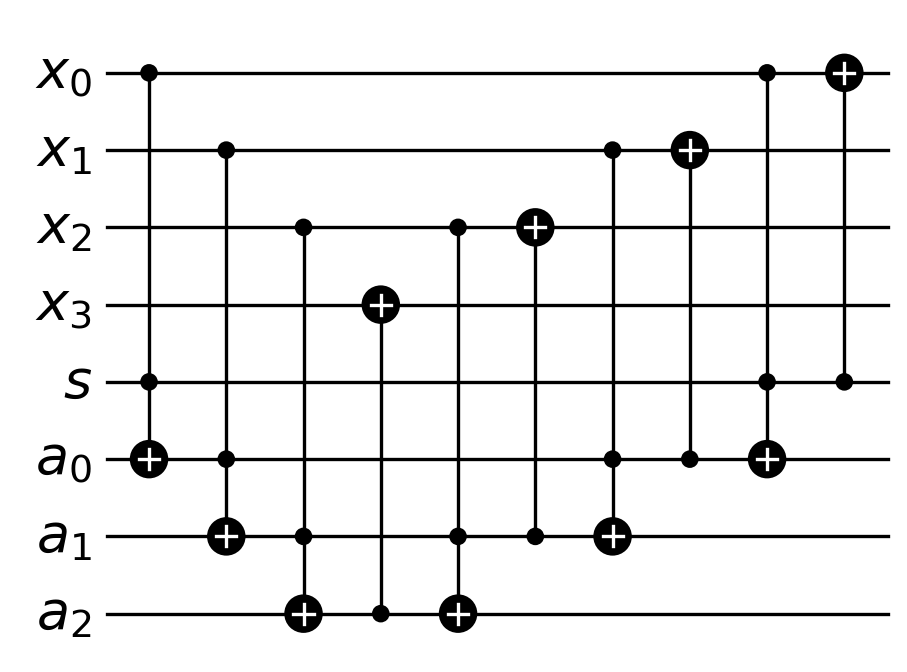

In [15]:
inc = increment_circuit(M_INC)
n = inc.count_ops()
print(f"m = {M_INC}:  {dict(n)},  {inc.num_qubits} qubits "
      f"(1 control + {M_INC} register + {max(M_INC - 1, 0)} carry)")
save_circuit(inc, None)


Reading it: `c` is the control, `x_0 ... x_{m-1}` the register with `x_0` least
significant, and the `a_k` the carry ancillas. The Toffolis on the way up build
the carry chain, the middle section flips and uncomputes on the way down, and
the final CX flips the least significant bit, which always flips.


In [16]:
for m in (2, 4, 8, 12):
    q = increment_circuit(m)
    n = q.count_ops()
    print(f"m = {m:2d}   Toffoli = {n.get('ccx',0):3d} (= 2m-2)   "
          f"CX = {n.get('cx',0):2d} (= m)   ancillas = {m-1}")

m =  2   Toffoli =   2 (= 2m-2)   CX =  2 (= m)   ancillas = 1
m =  4   Toffoli =   6 (= 2m-2)   CX =  4 (= m)   ancillas = 3
m =  8   Toffoli =  14 (= 2m-2)   CX =  8 (= m)   ancillas = 7
m = 12   Toffoli =  22 (= 2m-2)   CX = 12 (= m)   ancillas = 11


### 2.2 A full block encoding: 1D Poisson

$K = 2I - S_c - S_c^\dagger$, so $L=3$ and $\alpha=4$ at every size. The circuit
is $P_R^\dagger \cdot \mathrm{SELECT} \cdot P_L$, with

$$P_L|0\rangle = \sum_k \sqrt{|c_k|/\alpha}\,|k\rangle, \qquad
  P_R|0\rangle = \sum_k \mathrm{sgn}(c_k)\sqrt{|c_k|/\alpha}\,|k\rangle .$$

$P_R^\dagger$ is the adjoint of a *different* preparation, not the inverse of
$P_L$: the two vectors differ in sign wherever $c_k < 0$. That is where the
minus signs of $K$ enter, so $S_c$ is a bare permutation and no signs appear
inside SELECT.

This drawing and the three below are at `M` qubits per direction. Raise `M` in
the parameters cell to widen the register; the structure does not change.


m = 2:  6 qubits = 2 system + 2 prep + 1 select + 1 carry;   L = 3,  alpha = 4


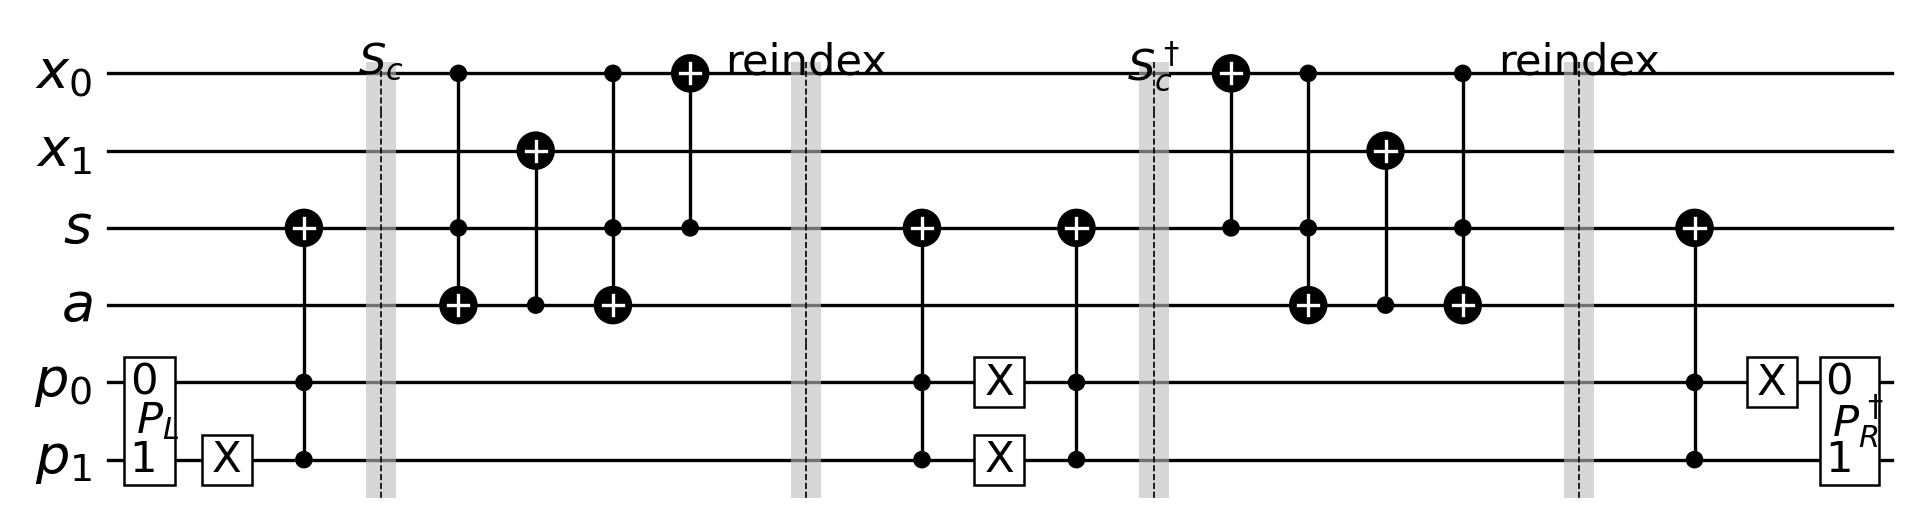

In [17]:
qc, info = blockencode(POISSON1D(), m=M)
print(f"m = {info.m}:  {info.qubits} qubits = {info.system} system + {info.prep} prep "
      f"+ 1 select + {info.carry} carry;   L = {info.L},  alpha = {info.alpha:g}")
save_circuit(qc, None,
             labels=['$S_c$', '$S_c^\\dagger$'],
             between='reindex')


Left to right: $P_L$ on the prep register; then one multiplexer per shift
value, each a Toffoli computing `s = (p == value)`, the controlled increment or
decrement, and the Toffoli again to uncompute `s`; then $P_R^\dagger$.

With `LABEL_STAGES = True` the barriers bracket what each multiplexer applies,
and the gaps between them are marked `reindex`, where the flag is cleared, the
prep index is recoded for the next term, and the flag is set again. The
identity term of the LCU has no bracket because it has no gates: $P_L$ puts
amplitude $\sqrt{2/4}$ on the index $p = 00$, and that branch passes through
SELECT untouched, which is exactly $c_0 I$. That is why $L = 3$ while the
circuit contains two shifts.


### 2.3 2D Poisson

$K = K_1 \otimes M_1 + M_1 \otimes K_1$, so $L = 9$. There is now one
multiplexer per spatial register, hence four controlled shifts in all. The term
count has risen from 3 to 9 and the shift count has not moved, because SELECT is
**factorised**: it is a product of one multiplexer per register rather than $L$
separately controlled blocks.


m = 2:  10 qubits, L = 9, and still only 4 controlled shifts


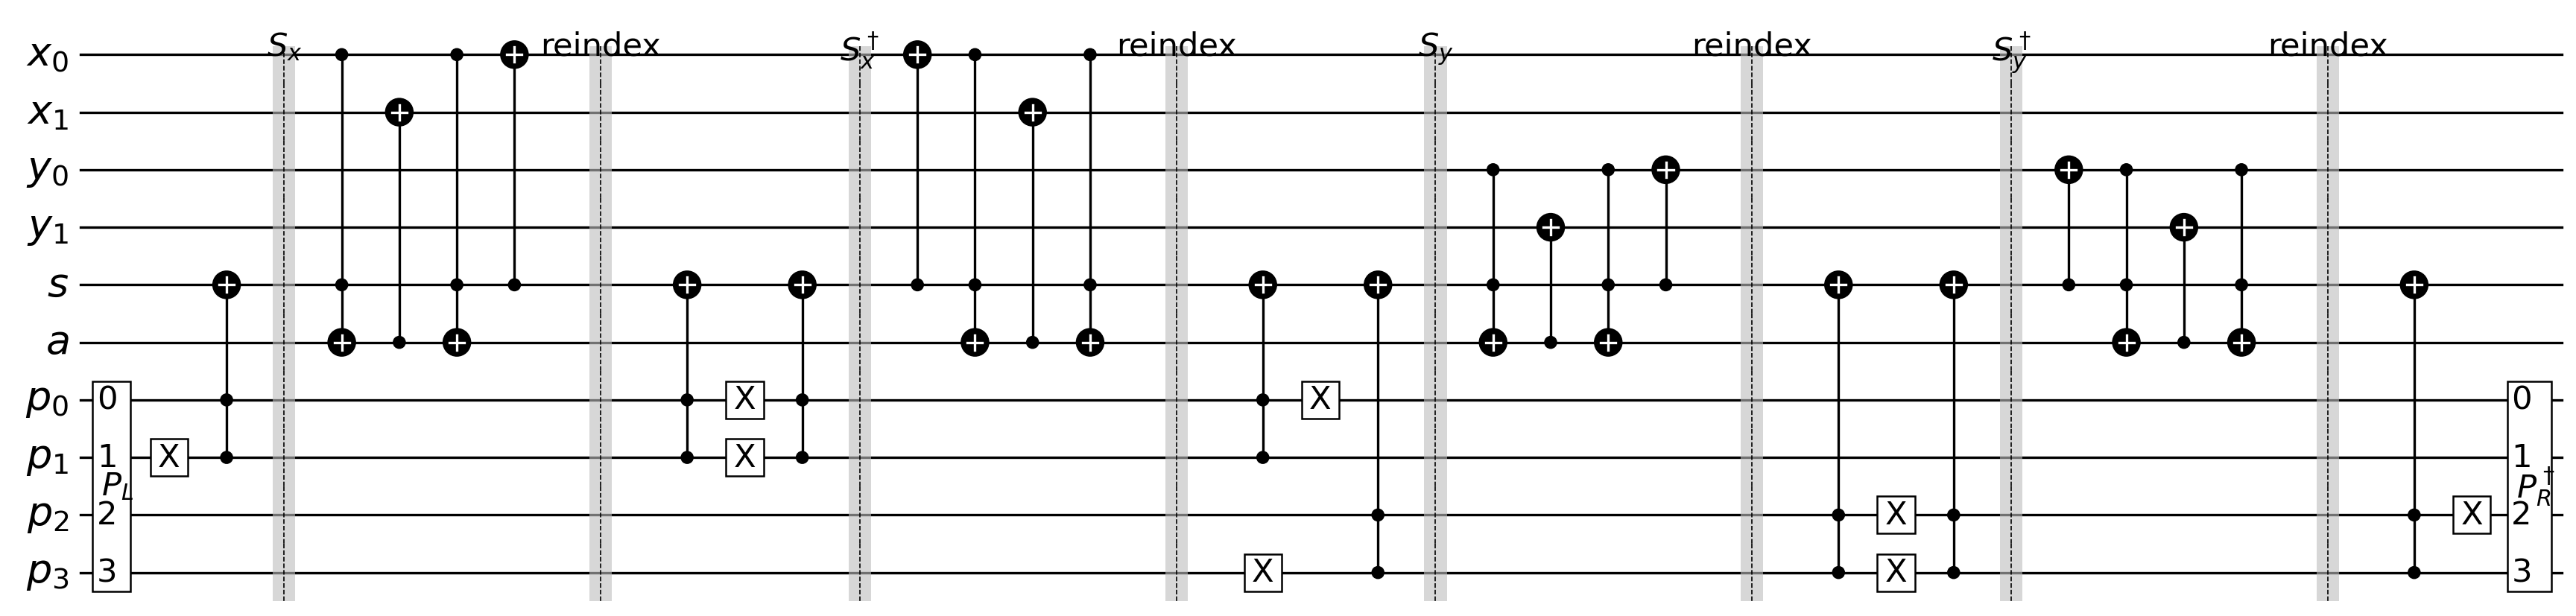

In [18]:
qc, info = blockencode(POISSON2D(), m=M)
print(f"m = {info.m}:  {info.qubits} qubits, L = {info.L}, "
      f"and still only 4 controlled shifts")
save_circuit(qc,None,
             labels=['$S_x$', '$S_x^\\dagger$', '$S_y$', '$S_y^\\dagger$'],
             between='reindex')


### 2.4 Elasticity

The dof qubit `d` carries the $\{I, Z, X\}$ components, so there is a third
multiplexer acting on it. $L = 17$, but the circuit still contains only four
controlled shifts, for the same reason.


m = 2:  13 qubits, L = 17, and still only 4 controlled shifts


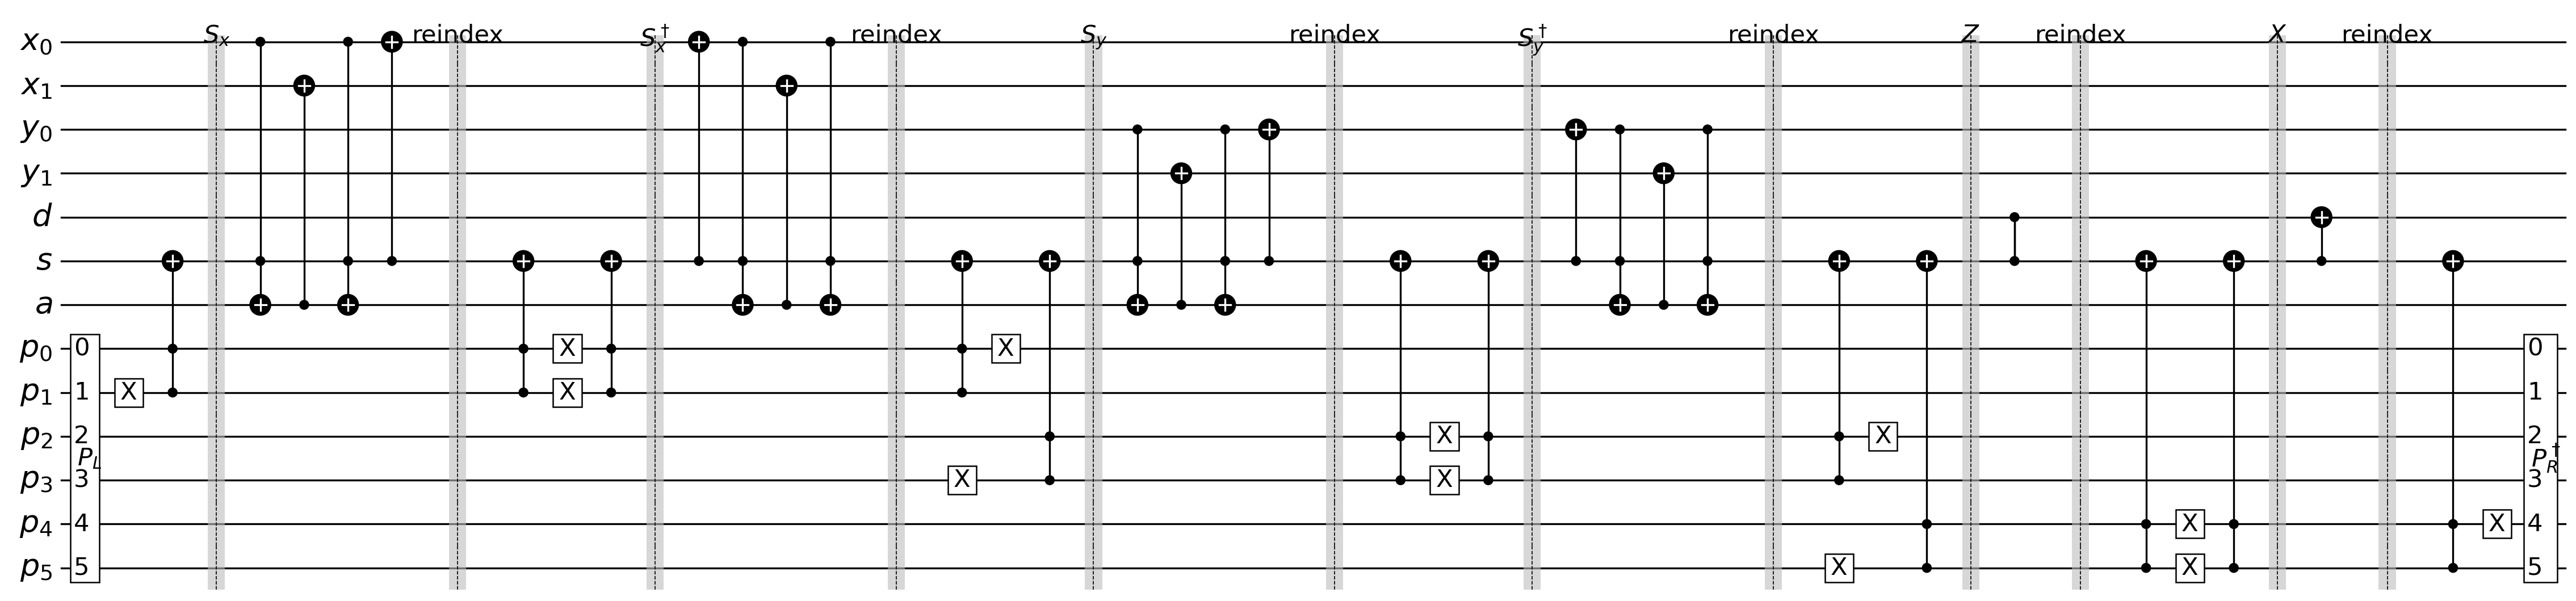

In [19]:
qc, info = blockencode(ELASTICITY2D(nu=NU), m=M)
print(f"m = {info.m}:  {info.qubits} qubits, L = {info.L}, "
      f"and still only 4 controlled shifts")
save_circuit(qc, None,
             labels=['$S_x$', '$S_x^\\dagger$', '$S_y$', '$S_y^\\dagger$',
                     '$Z$', '$X$'],
             between='reindex')


### 2.5 A two-phase cell

The material enters only through reflections $R_s = S^{(a,b)\dagger} R_\chi S^{(a,b)}$
with $R_\chi = I - 2\,\mathrm{diag}(\chi)$. So the reflection multiplexer is a
conditional shift, the oracle, and the shift undone. That conjugation adds four
controlled shifts to the four already there, which is the only place the shift
count ever changes. The oracle for a dyadic square inclusion is a single
multi-controlled Z whose width is set by the volume fraction, **not by m**.

The reflection selector is three one-bit fields (`g`, `a`, `b`), so its controls
are bare prep qubits and it needs no multi-controlled X at all.


m = 2:  13 qubits, L = 25, prep register 7 qubits, 8 controlled shifts


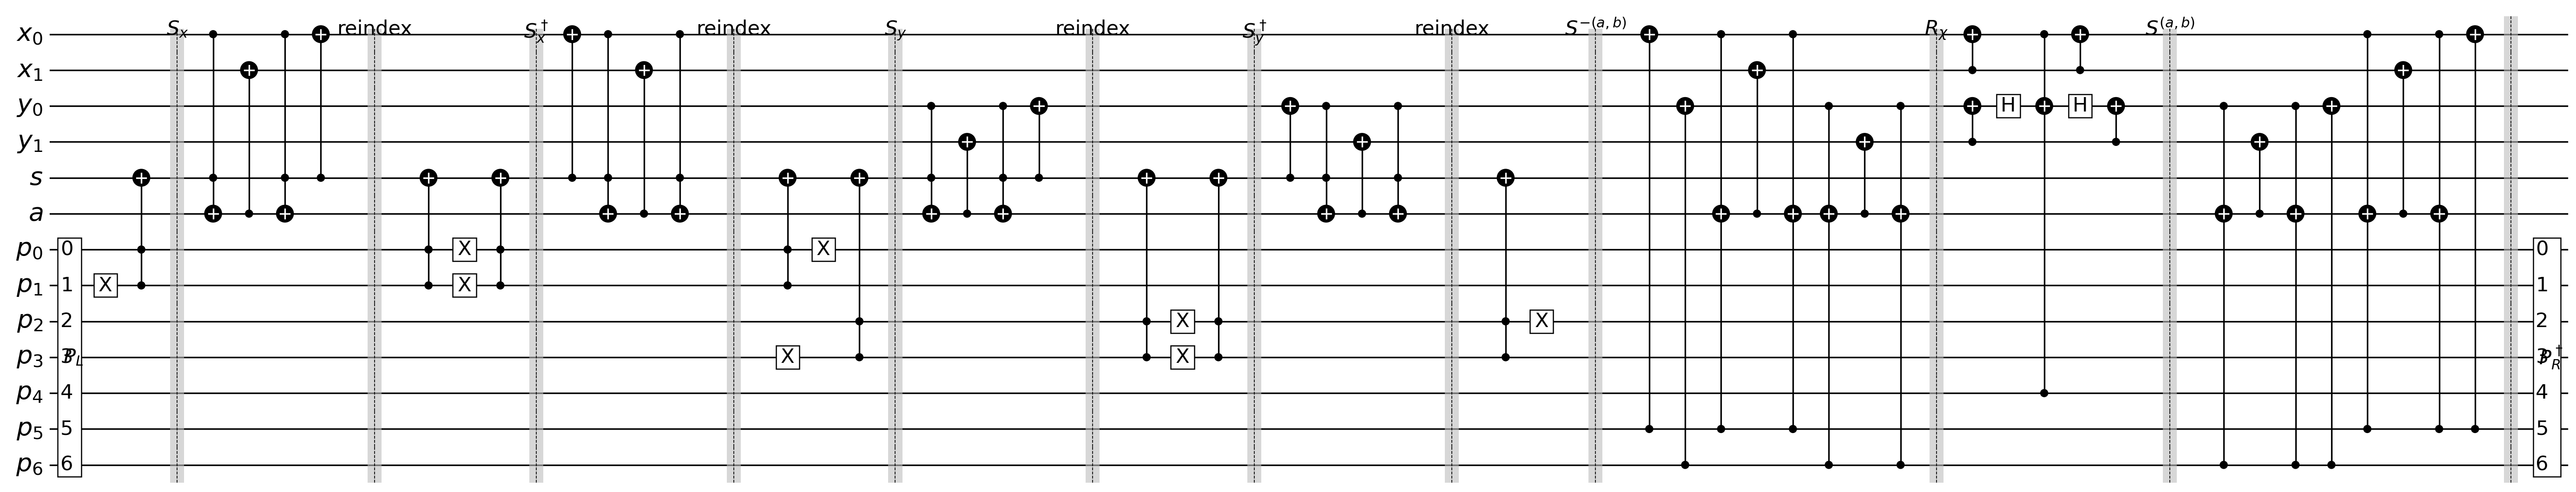

In [20]:
qc, info = blockencode(POISSON2D_2PHASE(vf=VF, E1=E1, E2=E2), m=M)
print(f"m = {info.m}:  {info.qubits} qubits, L = {info.L}, "
      f"prep register {info.prep} qubits, 8 controlled shifts")
save_circuit(qc, None,
             labels=['$S_x$', '$S_x^\\dagger$', '$S_y$', '$S_y^\\dagger$'],
             tail=['$S^{-(a,b)}$', '$R_\\chi$', '$S^{(a,b)}$'],
             between='reindex')


### 2.6 A two-phase elasticity cell

Both extensions at once: the dof qubit and the material reflection.
$L = 57$, and the circuit is the two-phase scalar cell of Section 2.5 with
three more single-qubit multiplexers on `d`, one per Pauli component. The
$iY$ component appears only at nonzero contrast, and vanishes at $\nu = 1/3$.


m = 2:  16 qubits, L = 57, prep register 9 qubits, 8 controlled shifts


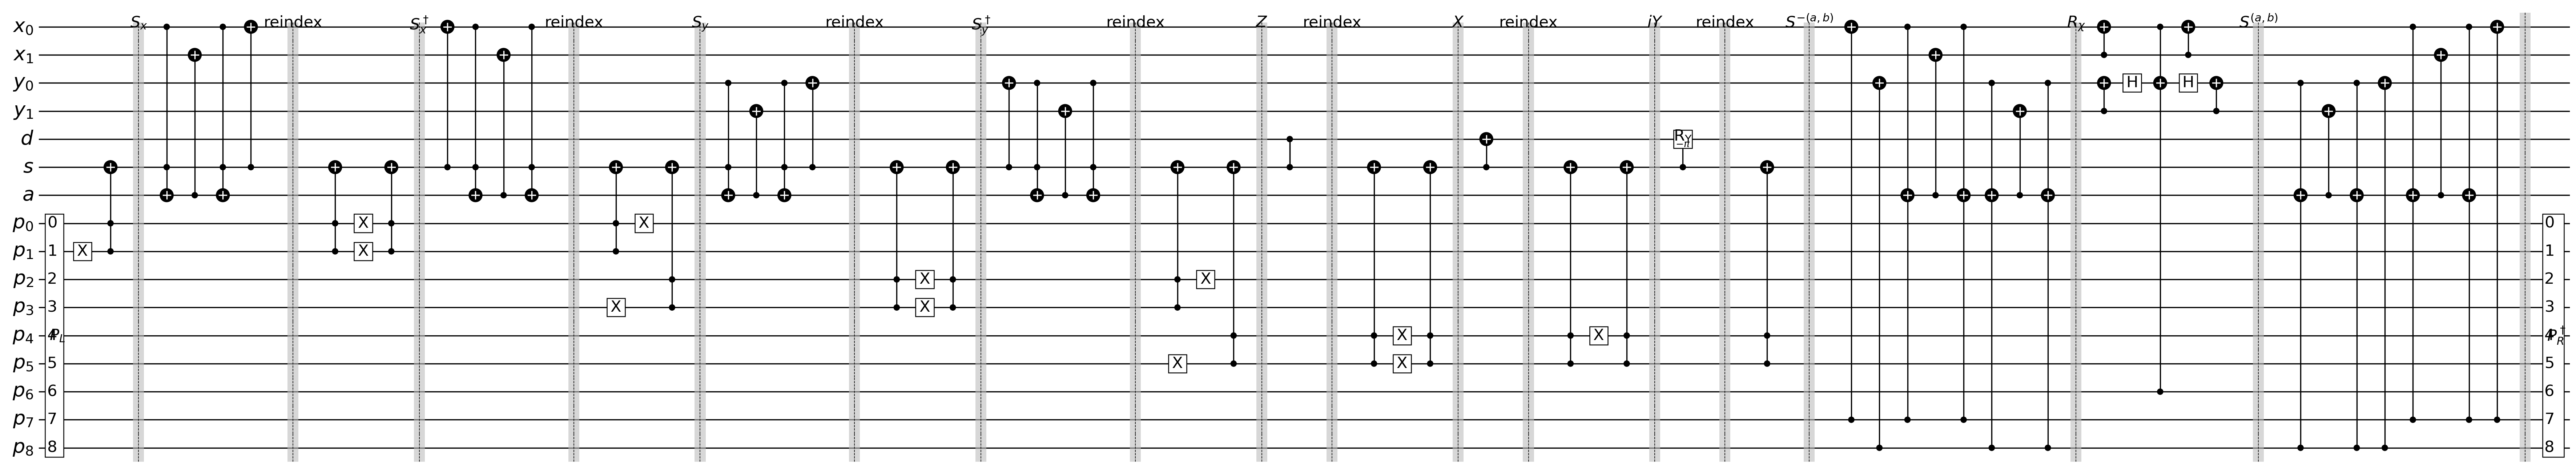

In [21]:
qc, info = blockencode(ELASTICITY2D_2PHASE(nu=NU, vf=VF, E1=E1, E2=E2), m=M)
print(f"m = {info.m}:  {info.qubits} qubits, L = {info.L}, "
      f"prep register {info.prep} qubits, 8 controlled shifts")
save_circuit(qc, None,
             labels=['$S_x$', '$S_x^\\dagger$', '$S_y$', '$S_y^\\dagger$',
                     '$Z$', '$X$', '$iY$'],
             tail=['$S^{-(a,b)}$', '$R_\\chi$', '$S^{(a,b)}$'],
             between='reindex')


## 3. Verification

`materialize=True` assembles $K$ densely and runs four independent checks. It
costs $O(4^n)$, so use it at small `m` only.

1. $\alpha$ against its closed form
2. the term list against a **direct element-by-element assembly** from Gauss
   quadrature, which uses no Kronecker identity and no LCU coefficient
3. $\alpha\,\langle 0|U|0\rangle$ against $K$
4. the same **after transpilation**, which is the check that catches a circuit
   that is correct as built but wrong once synthesised

In [22]:
for op, N in ((POISSON1D(), 16), (POISSON2D('fe'), 8),
              (ELASTICITY2D(nu=0.3), 4),
              (ELASTICITY2D_2PHASE(nu=0.3, vf=0.25, E1=10, E2=1), 4)):
    _, info = blockencode(op, N, materialize=True)
    print(info)
    print()

POISSON1D()   N = 16 per direction   m = 4 qubits/direction   dofs = 16
  L      = 3
  alpha  = 4.000000   (closed form 4.000000)
  qubits = 10  (system 4, prep 2, select 1, carry 3)
  Toffoli = 16   CX = 99   depth = 151      [transpiled to ['cx', 'u']]
  verified: alpha vs closed form  0.00e+00
            terms vs assembly     0.00e+00
            block vs K            6.93e-16
            block vs K transpiled 1.26e-14
            OK = True

POISSON2D(disc='fe')   N = 8 per direction   m = 3 qubits/direction   dofs = 64
  L      = 9
  alpha  = 5.333333   (closed form 5.333333)
  qubits = 13  (system 6, prep 4, select 1, carry 2)
  Toffoli = 24   CX = 169   depth = 264      [transpiled to ['cx', 'u']]
  verified: alpha vs closed form  8.88e-16
            terms vs assembly     4.44e-16
            block vs K            8.88e-15
            block vs K transpiled 3.10e-14
            OK = True

ELASTICITY2D(nu=0.3, E=1.0)   N = 4 per direction   m = 2 qubits/direction   dofs = 32
  L 

## 4. Two-phase cells

The whole point of the reflection form: $L$ and $\alpha$ depend on the element
and the contrast, and on nothing else. Not on `m`, not on the volume fraction,
not on which phase is stiffer.

In [23]:
print(f"{'vf':>9} {'E1':>4} {'E2':>4} {'m':>3} {'L':>4} {'alpha':>10}")
for vf in (0.25, 0.0625):
    for (E1, E2) in ((10, 1), (1, 10)):
        for m in (3, 5):
            be = PeriodicBlockEncoding(
                ELASTICITY2D_2PHASE(nu=0.3, vf=vf, E1=E1, E2=E2), m)
            print(f"{vf:>9.4f} {E1:>4} {E2:>4} {m:>3} {be.L:>4} {be.alpha:>10.5f}")

       vf   E1   E2   m    L      alpha
   0.2500   10    1   3   57   64.69780
   0.2500   10    1   5   57   64.69780
   0.2500    1   10   3   57   64.69780
   0.2500    1   10   5   57   64.69780
   0.0625   10    1   3   57   64.69780
   0.0625   10    1   5   57   64.69780
   0.0625    1   10   3   57   64.69780
   0.0625    1   10   5   57   64.69780


The two-phase subnormalizations have closed forms, both verified against
`element_alpha` to 1e-14:

$$\alpha_{\text{Poisson}} = \tfrac{16}{3}\max(E_1,E_2), \qquad
\alpha_{\text{elast}} = \frac{\tfrac12(E_1{+}E_2)(33{+}\nu)
+ |E_1{-}E_2|\left(18{+}2\nu{+}3|1{-}3\nu|\right)}{6(1-\nu^2)}$$

The scalar case collapses to a single term because $A=B=16/3$ there: the four
element contributions at a node never cancel, so contrast costs nothing beyond
scaling to the stiffer phase. The vector case does not collapse, and the
$|1-3\nu|$ is exactly the $iY$ component.

In [24]:
print(f"{'operator':>22} {'nu':>7} {'E1':>5} {'E2':>5} "
      f"{'element_alpha':>14} {'closed form':>12} {'err':>9}")
for E1, E2 in ((10, 1), (1, 10), (3, 1), (1, 1)):
    op = POISSON2D_2PHASE(vf=0.25, E1=E1, E2=E2)
    print(f"{op.kind:>22} {'-':>7} {E1:>5} {E2:>5} {op.alpha():>14.6f} "
          f"{op.alpha_published():>12.6f} {abs(op.alpha()-op.alpha_published()):>9.1e}")
for nu in (0.0, 0.3, 1/3, 0.45):
    op = ELASTICITY2D_2PHASE(nu=nu, vf=0.25, E1=10, E2=1)
    print(f"{op.kind:>22} {nu:>7.4f} {10:>5} {1:>5} {op.alpha():>14.6f} "
          f"{op.alpha_published():>12.6f} {abs(op.alpha()-op.alpha_published()):>9.1e}")

              operator      nu    E1    E2  element_alpha  closed form       err
      poisson2d_2phase       -    10     1      53.333333    53.333333   0.0e+00
      poisson2d_2phase       -     1    10      53.333333    53.333333   0.0e+00
      poisson2d_2phase       -     3     1      16.000000    16.000000   1.8e-15
      poisson2d_2phase       -     1     1       5.333333     5.333333   8.9e-16
   elasticity2d_2phase  0.0000    10     1      61.750000    61.750000   0.0e+00
   elasticity2d_2phase  0.3000    10     1      64.697802    64.697802   1.4e-14
   elasticity2d_2phase  0.3333    10     1      65.875000    65.875000   1.4e-14
   elasticity2d_2phase  0.4500    10     1      75.971787    75.971787   1.4e-14


Two structural facts worth seeing. At $\nu = 1/3$ the $iY$ component of the
dof register vanishes and the term count drops from 57 to 49. At zero contrast
the reflections drop out entirely and the operator collapses to the homogeneous
one, $L = 17$.

In [25]:
print(f"{'nu':>8} {'L':>4} {'alpha':>10} {'iY terms':>9}")
for nu in (0.0, 0.25, 0.3, 1/3, 0.4, 0.45):
    op = ELASTICITY2D_2PHASE(nu=nu, vf=0.25, E1=10, E2=1)
    t = op.terms()
    print(f"{nu:>8.4f} {len(t):>4} {sum(abs(v) for v in t.values()):>10.5f} "
          f"{sum(1 for k in t if k[2] == 3):>9}")

print()
for nu in (0.3, 1/3):
    z = ELASTICITY2D_2PHASE(nu=nu, vf=0.25, E1=1, E2=1)
    h = ELASTICITY2D(nu=nu)
    print(f"zero contrast, nu = {nu:.4f}:  L = {len(z.terms()):2d}, "
          f"alpha = {z.alpha():.6f}   vs homogeneous L = {len(h.terms())}, "
          f"alpha = {h.alpha():.6f}")

      nu    L      alpha  iY terms
  0.0000   57   61.75000         8
  0.2500   57   63.31111         8
  0.3000   57   64.69780         8
  0.3333   49   65.87500         0
  0.4000   57   71.09127         8
  0.4500   57   75.97179         8

zero contrast, nu = 0.3000:  L = 17, alpha = 6.098901   vs homogeneous L = 17, alpha = 6.098901
zero contrast, nu = 0.3333:  L = 17, alpha = 6.250000   vs homogeneous L = 17, alpha = 6.250000


## 5. Cost scaling

$L$ and $\alpha$ are fixed, so the only thing that grows with problem size is the
shift depth, and that grows linearly in $m = \log_2 N$.

In [26]:
MS = [2, 4, 6, 8, 10]
rows = {}
for op in OPS:
    rows[op.kind] = [blockencode(op, m=m)[1] for m in MS]

print(f"{'operator':>22} " + " ".join(f"{'m='+str(m):>8}" for m in MS))
for kind, infos in rows.items():
    print(f"{kind:>22} " + " ".join(f"{info.cx:>8}" for info in infos))

              operator      m=2      m=4      m=6      m=8     m=10
             poisson1d       51       99      147      195      243
          poisson2d_fd      121      217      313      409      505
          poisson2d_fe      121      217      313      409      505
          elasticity2d      239      335      431      527      623
      poisson2d_2phase      401      593      785      977     1169
   elasticity2d_2phase     1204     1396     1588     1780     1972


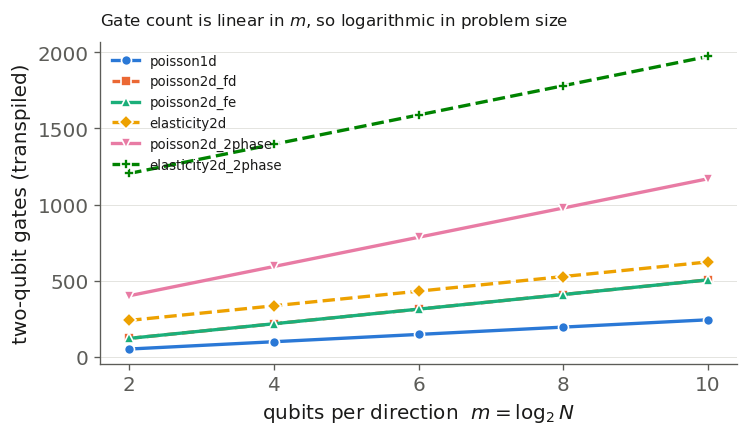

In [27]:
# poisson2d_fd and poisson2d_fe have identical circuits, so their curves
# coincide. Each series carries a distinct dash and marker as well as a hue,
# so identity is never colour alone.
STYLE = [('-', 'o'), ('--', 's'), ('-', '^'), ('--', 'D'), ('-', 'v'), ('--', 'P')]

fig, ax = plt.subplots(figsize=(6.4, 3.8))
for (kind, infos), c, (ls, mk) in zip(rows.items(), SERIES, STYLE):
    ax.plot(MS, [info.cx for info in infos], color=c, lw=2, ls=ls, marker=mk, ms=6,
            mec='white', mew=1.0, label=kind)
ax.set_xlabel('qubits per direction  $m = \\log_2 N$')
ax.set_ylabel('two-qubit gates (transpiled)')
ax.set_title('Gate count is linear in $m$, so logarithmic in problem size',
             loc='left', color=INK, fontsize=10, pad=10)
ax.set_xticks(MS)
ax.grid(axis='y', lw=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=8, loc='upper left', labelcolor=INK)
plt.tight_layout()
plt.show()

`poisson2d_fd` and `poisson2d_fe` lie on top of each other: they differ in
$L$ (5 against 9) and in $\alpha$ (8 against 16/3), but the circuit is the same
four controlled shifts either way, so the gate count is identical. That is the
factorised SELECT doing its job, and it is why $L$ alone is a poor proxy for cost
here.

The table above repeats the data in numbers, since several of these hues sit
below 3:1 against the surface.

## 6. What the encoding costs

Degrees of freedom grow like $4^m$ while the circuit grows like $m$. Plotted for
2D elasticity, one series, log scale on the vertical axis only.

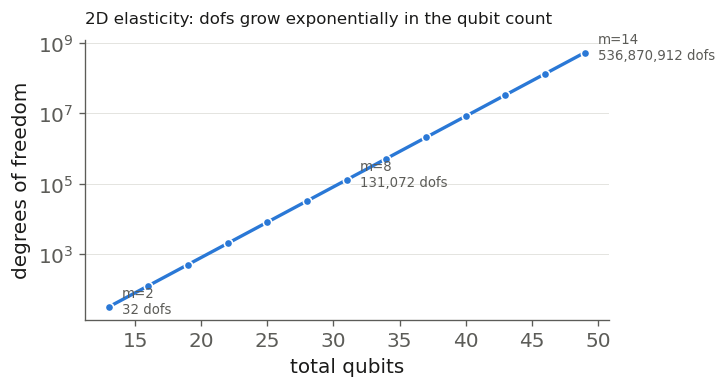

  m           dofs  qubits  Toffoli
  4            512      19       36
  8        131,072      31       68
 12     33,554,432      43      100
 14    536,870,912      49      116


In [28]:
ms = list(range(2, 15))
be = [PeriodicBlockEncoding(ELASTICITY2D(nu=0.3), m) for m in ms]
dofs = [2 ** b.n_system for b in be]
qub = [b.num_qubits for b in be]

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.plot(qub, dofs, color=SERIES[0], lw=2, marker='o', ms=5,
        mec='white', mew=1.0)
for k in (0, 6, 12):
    ax.annotate(f"m={ms[k]}\n{dofs[k]:,} dofs", (qub[k], dofs[k]),
                textcoords='offset points', xytext=(8, -4),
                fontsize=8, color=MUTED)
ax.set_yscale('log')
ax.set_xlabel('total qubits')
ax.set_ylabel('degrees of freedom')
ax.set_title('2D elasticity: dofs grow exponentially in the qubit count',
             loc='left', color=INK, fontsize=10, pad=10)
ax.grid(axis='y', lw=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"{'m':>3} {'dofs':>14} {'qubits':>7} {'Toffoli':>8}")
for m in (4, 8, 12, 14):
    _, info = blockencode(ELASTICITY2D(nu=0.3), m=m)
    print(f"{m:>3} {info.dofs:>14,} {info.qubits:>7} {info.toffoli:>8}")

## 7. Looking inside

The term list and the assembled matrix are available when you want them.

In [29]:
op = POISSON1D()
print("terms, keyed by shift code (0 = I, 1 = S, 2 = S-dagger):")
for k, v in op.terms().items():
    print(f"  {k}  ->  {v:+.4f}")

be = PeriodicBlockEncoding(op, m=3)
K = be.matrix()
print(f"\nK for m = 3, first rows:\n{K[:4, :8]}")
print(f"\nalpha = {be.alpha}, ||K||_2 = {np.linalg.norm(K, 2):.6f}, "
      f"alpha/||K||_2 = {be.alpha / np.linalg.norm(K, 2):.6f}")

terms, keyed by shift code (0 = I, 1 = S, 2 = S-dagger):
  (0,)  ->  +2.0000
  (1,)  ->  -1.0000
  (2,)  ->  -1.0000

K for m = 3, first rows:
[[ 2. -1.  0.  0.  0.  0.  0. -1.]
 [-1.  2. -1.  0.  0.  0.  0.  0.]
 [ 0. -1.  2. -1.  0.  0.  0.  0.]
 [ 0.  0. -1.  2. -1.  0.  0.  0.]]

alpha = 4.0, ||K||_2 = 4.000000, alpha/||K||_2 = 1.000000
